In [14]:
library(ggplot2)



In [18]:
FILE <- "/home/benjamin/Projects/santa_cruz_waves/data/raw/46236.data_spec"

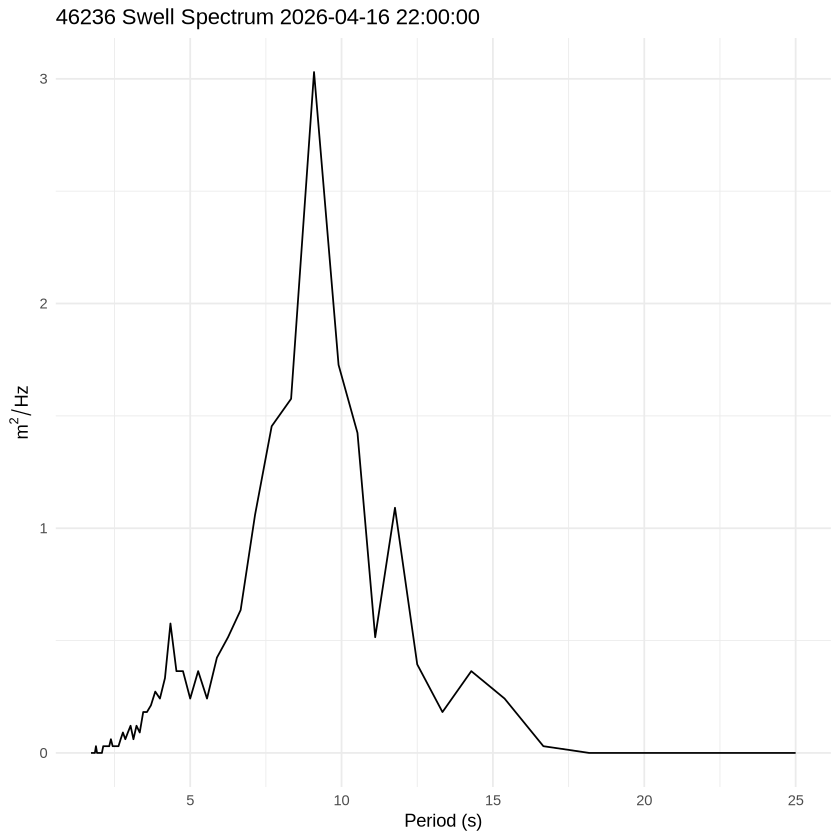

In [22]:

library(ggplot2)

lines <- readLines(FILE)

# keep only data rows
data_lines <- lines[!grepl("^#", lines)]

# most recent snapshot = first data row
latest_line <- data_lines[1]

parts <- scan(text = latest_line, what = character(), quiet = TRUE)

# first 6 fields: YYYY MM DD hh mm Sep_Freq
yr <- as.integer(parts[1])
mo <- as.integer(parts[2])
dy <- as.integer(parts[3])
hr <- as.integer(parts[4])
mi <- as.integer(parts[5])
sep_freq <- as.numeric(parts[6])

# build UTC timestamp
timestamp_utc <- as.POSIXct(
  sprintf("%04d-%02d-%02d %02d:%02d", yr, mo, dy, hr, mi),
  format = "%Y-%m-%d %H:%M",
  tz = "UTC"
)

# remaining fields alternate: energy, frequency label
spec_parts <- parts[-(1:6)]

energy_vals <- spec_parts[seq(1, length(spec_parts), by = 2)]
freq_labels <- spec_parts[seq(2, length(spec_parts), by = 2)]

energy <- as.numeric(energy_vals)
freq_hz <- as.numeric(gsub("[()]", "", freq_labels))

df <- data.frame(
  timestamp_utc = timestamp_utc,
  frequency_hz = freq_hz,
  period_s = 1 / freq_hz,
  energy = energy
)

df <- df[df$period_s <= 25, ]

df <- df[
  is.finite(df$frequency_hz) &
    is.finite(df$period_s) &
    is.finite(df$energy),
]

p <- ggplot(df, aes(x = period_s, y = energy)) +
  geom_line() +
  labs(
    title = paste("46236 Swell Spectrum", format(timestamp_utc, tz = "UTC")),
    x = "Period (s)",
    y = expression(m^2/Hz)
  ) +
  theme_minimal()

print(p)

# for each peak I want to show a representative direction and power

# smooth, local peaks?
# gaussian mixture?

In [26]:
library(pracma)

get_swell_peaks <- function(df, smooth_k = 3, min_peak_frac = 0.12) {
  df <- df[order(df$period_s), ]

  # simple moving average smoothing
  smooth_vals <- stats::filter(df$energy, rep(1 / smooth_k, smooth_k), sides = 2)
  df$energy_smooth <- as.numeric(smooth_vals)

  # edge fallback: use raw values where smoothing produced NA
  na_idx <- is.na(df$energy_smooth)
  df$energy_smooth[na_idx] <- df$energy[na_idx]

  peaks <- findpeaks(
    df$energy_smooth,
    nups = 1,
    ndowns = 1,
    minpeakheight = max(df$energy_smooth, na.rm = TRUE) * min_peak_frac
  )

  if (is.null(peaks)) {
    peak_df <- data.frame(period_s = numeric(), energy_smooth = numeric())
  } else {
    peak_idx <- peaks[, 2]
    peak_df <- df[peak_idx, c("period_s", "energy", "energy_smooth")]
    peak_df <- peak_df[order(-peak_df$energy_smooth), ]
  }

  list(df = df, peaks = peak_df)
}



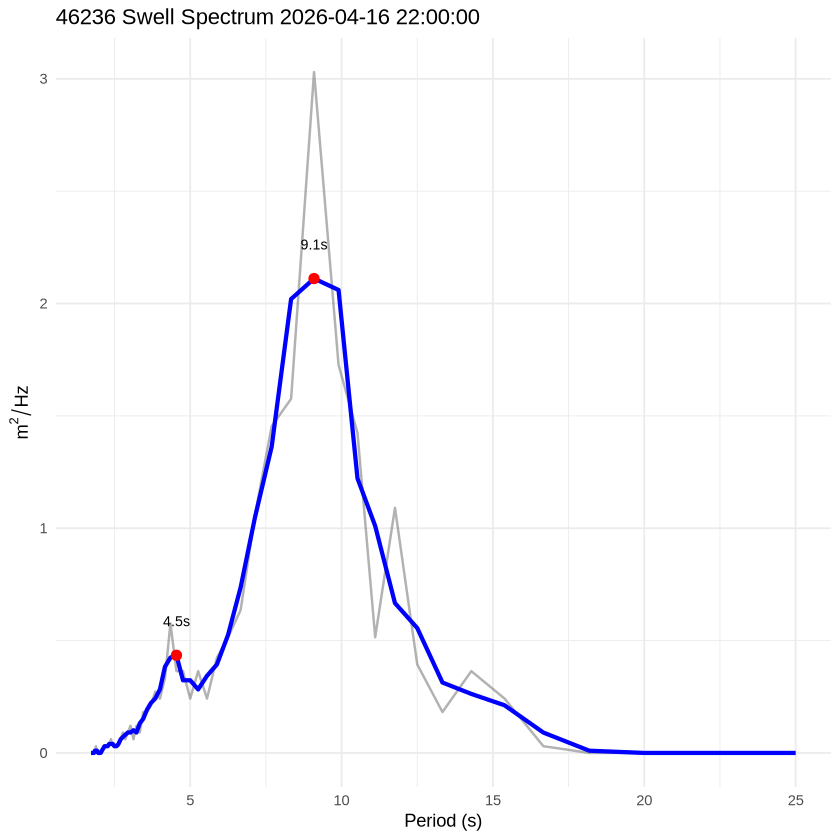

In [28]:
res <- get_swell_peaks(df)

df_plot <- res$df
peak_df <- res$peaks

p <- ggplot(df_plot, aes(x = period_s)) +
  geom_line(aes(y = energy), linewidth = 0.7, alpha = 0.5, color = "gray40") +
  geom_line(aes(y = energy_smooth), linewidth = 1.2, color = "blue") +
  geom_point(
    data = peak_df,
    aes(y = energy_smooth),
    size = 2.5,
    color = "red"
  ) +
  geom_text(
    data = peak_df,
    aes(y = energy_smooth, label = sprintf("%.1fs", period_s)),
    nudge_y = 0.05 * max(df_plot$energy, na.rm = TRUE),
    size = 3
  ) +
  labs(
    title = paste("46236 Swell Spectrum", format(timestamp_utc, tz = "UTC")),
    x = "Period (s)",
    y = expression(m^2/Hz)
  ) +
  theme_minimal()

print(p)

# Scratch

In [1]:
FILE <- "/home/benjamin/Projects/santa_cruz_waves/data/raw/46236.data_spec"

# what is difference
SWDIR_FILE <- "/home/benjamin/Projects/santa_cruz_waves/data/raw/46236.swdir"


In [24]:
plot_spectrum_with_direction <- function(spec_file,
                                         swdir_file,
                                         station_id = NULL,
                                         period_min = 3,
                                         period_max = 25,
                                         arrow_spacing_s = 2) {
  library(ggplot2)
  library(dplyr)
  library(pracma)

  `%||%` <- function(a, b) if (!is.null(a)) a else b

  deg_to_compass <- function(deg) {
    dirs <- c("N", "NE", "E", "SE", "S", "SW", "W", "NW")
    ix <- round((deg %% 360) / 45) %% 8 + 1
    dirs[ix]
  }

  read_ndbc_spec <- function(file) {
    lines <- readLines(file)
    data_lines <- lines[!grepl("^#", lines)]

    latest_line <- data_lines[1]
    parts <- scan(text = latest_line, what = character(), quiet = TRUE)

    yr <- as.integer(parts[1])
    mo <- as.integer(parts[2])
    dy <- as.integer(parts[3])
    hr <- as.integer(parts[4])
    mi <- as.integer(parts[5])
    sep_freq <- as.numeric(parts[6])

    timestamp_utc <- as.POSIXct(
      sprintf("%04d-%02d-%02d %02d:%02d", yr, mo, dy, hr, mi),
      format = "%Y-%m-%d %H:%M",
      tz = "UTC"
    )

    spec_parts <- parts[-(1:6)]
    energy_vals <- spec_parts[seq(1, length(spec_parts), by = 2)]
    freq_labels <- spec_parts[seq(2, length(spec_parts), by = 2)]

    df <- data.frame(
      timestamp_utc = timestamp_utc,
      frequency_hz = as.numeric(gsub("[()]", "", freq_labels)),
      energy = as.numeric(energy_vals),
      sep_freq = sep_freq
    )

    df$period_s <- 1 / df$frequency_hz

    df |>
      filter(
        is.finite(frequency_hz),
        is.finite(period_s),
        is.finite(energy),
        period_s >= period_min,
        period_s <= period_max
      ) |>
      arrange(period_s)
  }

  read_ndbc_swdir <- function(file) {
    lines <- readLines(file)
    data_lines <- lines[!grepl("^#", lines)]

    latest_line <- data_lines[1]
    parts <- scan(text = latest_line, what = character(), quiet = TRUE)

    yr <- as.integer(parts[1])
    mo <- as.integer(parts[2])
    dy <- as.integer(parts[3])
    hr <- as.integer(parts[4])
    mi <- as.integer(parts[5])

    timestamp_utc <- as.POSIXct(
      sprintf("%04d-%02d-%02d %02d:%02d", yr, mo, dy, hr, mi),
      format = "%Y-%m-%d %H:%M",
      tz = "UTC"
    )

    dir_parts <- parts[-(1:5)]
    dir_vals <- dir_parts[seq(1, length(dir_parts), by = 2)]
    freq_labels <- dir_parts[seq(2, length(dir_parts), by = 2)]

    df <- data.frame(
      timestamp_utc = timestamp_utc,
      frequency_hz = as.numeric(gsub("[()]", "", freq_labels)),
      direction_deg = as.numeric(dir_vals)
    )

    df$period_s <- 1 / df$frequency_hz
    df$direction_deg[df$direction_deg >= 999] <- NA_real_

    df |>
      filter(
        is.finite(frequency_hz),
        is.finite(period_s),
        period_s >= period_min,
        period_s <= period_max
      ) |>
      mutate(
        direction_deg = ifelse(direction_deg < 0 | direction_deg > 360,
                               NA_real_,
                               direction_deg)
      ) |>
      arrange(period_s)
  }

  spec_df <- read_ndbc_spec(spec_file)
  dir_df <- read_ndbc_swdir(swdir_file)

  df <- spec_df |>
    left_join(
      dir_df |> select(frequency_hz, direction_deg),
      by = "frequency_hz"
    ) |>
    arrange(period_s)

  # Smooth spectrum
  smooth_k <- 2
  smooth_vals <- stats::filter(df$energy, rep(1 / smooth_k, smooth_k), sides = 2)
  df$energy_smooth <- as.numeric(smooth_vals)
  df$energy_smooth[is.na(df$energy_smooth)] <- df$energy[is.na(df$energy_smooth)]

  # Find peaks
  peaks <- findpeaks(
    df$energy_smooth,
    nups = 1,
    ndowns = 1,
    minpeakheight = max(df$energy_smooth, na.rm = TRUE) * 0.12
  )

  if (is.null(peaks)) {
    peak_df <- data.frame(
      period_s = numeric(),
      energy = numeric(),
      energy_smooth = numeric(),
      direction_deg = numeric(),
      power_raw = numeric(),
      power_pct = numeric(),
      dir_label = character(),
      label = character()
    )
  } else {
    peak_idx <- peaks[, 2]

    peak_df <- df[peak_idx, c("period_s", "energy", "energy_smooth", "direction_deg")]
    peak_df <- peak_df[order(-peak_df$energy_smooth), ]

    peak_df <- peak_df |>
      mutate(
        power_raw = energy_smooth * period_s
      )

    total_power <- sum(peak_df$power_raw, na.rm = TRUE)

    peak_df <- peak_df |>
      mutate(
        power_pct = if (total_power > 0) 100 * power_raw / total_power else NA_real_,
        dir_label = ifelse(is.na(direction_deg), "", deg_to_compass(direction_deg)),
        label = ifelse(
          dir_label == "",
          sprintf("%.1fs\n%.0f%%", period_s, power_pct),
          sprintf("%.1fs %s\n%.0f%%", period_s, dir_label, power_pct)
        )
      )
  }

  # Direction arrows every fixed number of seconds
  arrow_candidates <- df |>
    filter(is.finite(direction_deg)) |>
    arrange(period_s)

  if (nrow(arrow_candidates) > 0) {
    arrow_periods <- seq(
      ceiling(min(df$period_s, na.rm = TRUE)),
      floor(max(df$period_s, na.rm = TRUE)),
      by = arrow_spacing_s
    )

    idx <- sapply(arrow_periods, function(tp) {
      which.min(abs(arrow_candidates$period_s - tp))
    })

    arrow_df <- arrow_candidates[idx, , drop = FALSE] |>
      distinct(period_s, .keep_all = TRUE) |>
      arrange(period_s)
  } else {
    arrow_df <- data.frame()
  }

  ymax <- max(df$energy_smooth, na.rm = TRUE)
  yspan <- ymax

  if (nrow(arrow_df) > 0) {
    y_arrow <- -0.10 * yspan
    xspan <- diff(range(df$period_s, na.rm = TRUE))
    x_len <- 0.05 * xspan
    y_len <- 0.07 * yspan

    # NDBC direction is "from"; flip 180 so arrows show travel direction
    dir_toward <- (arrow_df$direction_deg + 180) %% 360
    angle_rad <- (90 - dir_toward) * pi / 180

    arrow_df <- arrow_df |>
      mutate(
        y_arrow = y_arrow,
        xend = period_s + x_len * cos(angle_rad),
        yend = y_arrow + y_len * sin(angle_rad)
      )
  }

  p <- ggplot(df, aes(x = period_s)) +
    geom_line(aes(y = energy), linewidth = 0.7, alpha = 0.5, color = "gray40") +
    geom_line(aes(y = energy_smooth), linewidth = 1.2, color = "blue") +
    geom_point(
      data = peak_df,
      aes(y = energy_smooth),
      size = 2.5,
      color = "red"
    ) +
    geom_text(
      data = peak_df,
      aes(y = energy_smooth, label = label),
      nudge_y = 0.05 * max(df$energy, na.rm = TRUE),
      size = 3
    ) +
    labs(
      title = paste(
        station_id %||% "Station",
        "Swell Spectrum",
        format(spec_df$timestamp_utc[1], tz = "UTC")
      ),
      x = "Period (s)",
      y = expression(m^2 / Hz)
    ) +
    coord_cartesian(
      ylim = c(-0.16 * yspan, ymax * 1.12),
      clip = "off"
    ) +
    theme_minimal() +
    theme(
      plot.margin = margin(10, 20, 30, 20)
    )

  if (nrow(arrow_df) > 0) {
    p <- p +
      geom_segment(
        data = arrow_df,
        aes(
          x = period_s,
          y = y_arrow,
          xend = xend,
          yend = yend
        ),
        inherit.aes = FALSE,
        arrow = grid::arrow(length = grid::unit(0.16, "inches")),
        linewidth = 0.7,
        color = "darkgreen"
      )
  }

  p
}

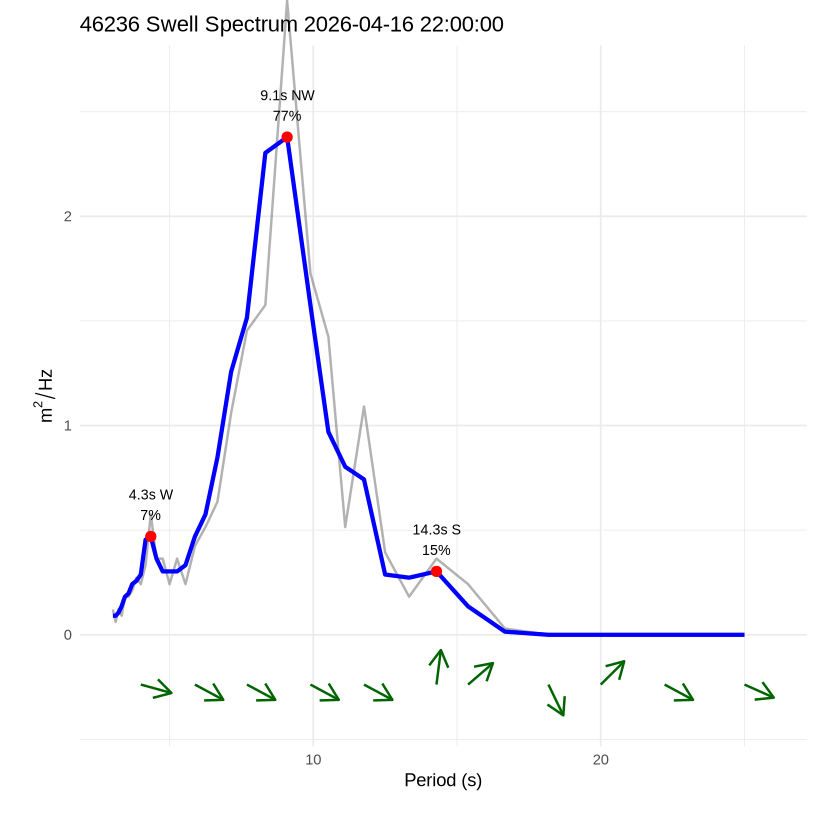

In [26]:
plot_spectrum_with_direction(
  spec_file  = FILE,
  swdir_file = SWDIR_FILE,
  station_id = "46236",
)

